# ============================================================
# CAPSTONE PROJECT
# NOTEBOOK 36: EXPANDED HYBRID MULTI-LABEL FUSION
# ============================================================
# Purpose:
# This notebook combines the structured and audio multi-label
# branches on the exact expanded candidate-150 validation and
# test sets.
#
# The goal is to:
# 1. Load aligned structured and expanded audio outputs
# 2. Verify track, label, and target alignment
# 3. Fuse structured and audio probabilities
# 4. Tune fusion weights and threshold on validation data
# 5. Evaluate the best expanded hybrid model on the test set
# 6. Compare structured vs expanded audio vs expanded hybrid
# ============================================================

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    f1_score,
    hamming_loss,
    accuracy_score,
    precision_score,
    recall_score
)

SEED = 42
np.random.seed(SEED)

print("Seed set to:", SEED)

Seed set to: 42


In [2]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    f1_score,
    hamming_loss,
    accuracy_score,
    precision_score,
    recall_score
)

SEED = 42
np.random.seed(SEED)

print("Seed set to:", SEED)

Seed set to: 42


In [3]:
# ============================================================
# 2. LOAD STRUCTURED EXPANDED OUTPUTS
# ============================================================

structured_val_probs = np.load("../data/processed/structured_on_expanded_audio_candidate150_val_probs.npy")
structured_test_probs = np.load("../data/processed/structured_on_expanded_audio_candidate150_test_probs.npy")

structured_y_val = np.load("../data/processed/structured_on_expanded_audio_candidate150_y_val.npy")
structured_y_test = np.load("../data/processed/structured_on_expanded_audio_candidate150_y_test.npy")

structured_val_track_ids = np.load("../data/processed/structured_on_expanded_audio_candidate150_val_track_ids.npy")
structured_test_track_ids = np.load("../data/processed/structured_on_expanded_audio_candidate150_test_track_ids.npy")

structured_label_cols = np.load(
    "../data/processed/structured_on_expanded_audio_candidate150_label_columns.npy",
    allow_pickle=True
)

structured_val_results_df = pd.read_csv(
    "../data/processed/structured_on_expanded_audio_candidate150_val_results.csv"
)
structured_test_results_df = pd.read_csv(
    "../data/processed/structured_on_expanded_audio_candidate150_test_results.csv"
)

print("Structured expanded validation probabilities shape:", structured_val_probs.shape)
print("Structured expanded test probabilities shape:", structured_test_probs.shape)
print("Structured expanded y_val shape:", structured_y_val.shape)
print("Structured expanded y_test shape:", structured_y_test.shape)

display(structured_test_results_df)

Structured expanded validation probabilities shape: (1500, 150)
Structured expanded test probabilities shape: (1500, 150)
Structured expanded y_val shape: (1500, 150)
Structured expanded y_test shape: (1500, 150)


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels
0,Structured Model on Expanded Audio Split - Test,0.1637,0.082346,0.164799,0.095782,0.562713,0.142409,0.0,21.827333


In [4]:
# ============================================================
# 3. LOAD EXPANDED AUDIO OUTPUTS
# ============================================================

audio_val_probs = np.load("../data/processed/audio_multilabel_candidate150_expanded_val_probs.npy")
audio_test_probs = np.load("../data/processed/audio_multilabel_candidate150_expanded_test_probs.npy")

audio_y_val = np.load("../data/processed/audio_multilabel_candidate150_expanded_y_val.npy")
audio_y_test = np.load("../data/processed/audio_multilabel_candidate150_expanded_y_test.npy")

audio_val_track_ids = np.load("../data/processed/audio_multilabel_candidate150_expanded_val_track_ids.npy")
audio_test_track_ids = np.load("../data/processed/audio_multilabel_candidate150_expanded_test_track_ids.npy")

audio_label_cols = np.load(
    "../data/processed/audio_multilabel_candidate150_expanded_label_columns.npy",
    allow_pickle=True
)

audio_test_comparison_df = pd.read_csv(
    "../data/processed/audio_multilabel_candidate150_expanded_test_comparison.csv"
)

with open("../data/processed/audio_multilabel_candidate150_expanded_best_threshold.txt", "r") as f:
    audio_best_threshold = float(f.read().strip())

print("Expanded audio validation probabilities shape:", audio_val_probs.shape)
print("Expanded audio test probabilities shape:", audio_test_probs.shape)
print("Expanded audio y_val shape:", audio_y_val.shape)
print("Expanded audio y_test shape:", audio_y_test.shape)
print("Expanded audio best threshold:", audio_best_threshold)

display(audio_test_comparison_df)

Expanded audio validation probabilities shape: (1500, 150)
Expanded audio test probabilities shape: (1500, 150)
Expanded audio y_val shape: (1500, 150)
Expanded audio y_test shape: (1500, 150)
Expanded audio best threshold: 0.2


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels,Precision@3,Recall@3,Precision@5,Recall@5
0,Expanded Audio CNN - Default Threshold,0.222419,0.012375,0.215533,0.620888,0.135475,0.023462,0.010000,0.810667,0.423111,0.374371,0.328533,0.476267
1,Expanded Audio CNN - Tuned Threshold,0.381704,0.040540,0.379117,0.406029,0.360129,0.028898,0.001333,3.295333,0.423111,0.374371,0.328533,0.476267


In [5]:
# ============================================================
# 4. VERIFY FULL ALIGNMENT
# ============================================================

print("Label columns match:",
      np.array_equal(structured_label_cols, audio_label_cols))

print("Validation track IDs match:",
      np.array_equal(structured_val_track_ids, audio_val_track_ids))

print("Test track IDs match:",
      np.array_equal(structured_test_track_ids, audio_test_track_ids))

print("Validation targets match:",
      np.array_equal(structured_y_val, audio_y_val))

print("Test targets match:",
      np.array_equal(structured_y_test, audio_y_test))

assert np.array_equal(structured_label_cols, audio_label_cols), "Label columns do not match."
assert np.array_equal(structured_val_track_ids, audio_val_track_ids), "Validation track IDs do not match."
assert np.array_equal(structured_test_track_ids, audio_test_track_ids), "Test track IDs do not match."
assert np.array_equal(structured_y_val, audio_y_val), "Validation targets do not match."
assert np.array_equal(structured_y_test, audio_y_test), "Test targets do not match."

Label columns match: True
Validation track IDs match: True
Test track IDs match: True
Validation targets match: True
Test targets match: True


In [6]:
# ============================================================
# 5. DEFINE COMMON TARGETS
# ============================================================

Y_val = structured_y_val.copy()
Y_test = structured_y_test.copy()
label_cols = structured_label_cols.copy()

print("Y_val shape:", Y_val.shape)
print("Y_test shape:", Y_test.shape)
print("Number of labels:", len(label_cols))

Y_val shape: (1500, 150)
Y_test shape: (1500, 150)
Number of labels: 150


In [7]:
# ============================================================
# 6. EVALUATION HELPERS
# ============================================================

def evaluate_multilabel(y_true, y_pred, name="Model"):
    return {
        "Model": name,
        "Micro F1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Samples F1": f1_score(y_true, y_pred, average="samples", zero_division=0),
        "Micro Precision": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "Micro Recall": recall_score(y_true, y_pred, average="micro", zero_division=0),
        "Hamming Loss": hamming_loss(y_true, y_pred),
        "Subset Accuracy": accuracy_score(y_true, y_pred),
        "Avg Predicted Labels": float(y_pred.sum(axis=1).mean())
    }

def precision_recall_at_k(y_true, score_matrix, k=3):
    y_true = np.asarray(y_true)
    topk_idx = np.argsort(-score_matrix, axis=1)[:, :k]

    precision_vals = []
    recall_vals = []

    for i in range(y_true.shape[0]):
        true_idx = np.where(y_true[i] == 1)[0]
        if len(true_idx) == 0:
            continue

        pred_idx = topk_idx[i]
        hits = len(set(pred_idx).intersection(set(true_idx)))

        precision_vals.append(hits / k)
        recall_vals.append(hits / len(true_idx))

    return float(np.mean(precision_vals)), float(np.mean(recall_vals))

def decode_threshold(prob_matrix, threshold, ensure_at_least_one=False):
    y_pred = (prob_matrix >= threshold).astype(np.uint8)

    if ensure_at_least_one:
        row_sums = y_pred.sum(axis=1)
        zero_rows = np.where(row_sums == 0)[0]

        if len(zero_rows) > 0:
            top_idx = np.argmax(prob_matrix[zero_rows], axis=1)
            y_pred[zero_rows, top_idx] = 1

    return y_pred

def fuse_probabilities(structured_probs, audio_probs, w_structured=0.5, w_audio=0.5):
    return (w_structured * structured_probs) + (w_audio * audio_probs)

In [8]:
# ============================================================
# 7. BASELINE COMPARISON ON THE SAME EXPANDED SPLIT
# ============================================================

structured_baseline_pred = decode_threshold(structured_val_probs, 0.5, ensure_at_least_one=False)
audio_baseline_pred = decode_threshold(audio_val_probs, audio_best_threshold, ensure_at_least_one=False)

structured_baseline_results = evaluate_multilabel(
    Y_val, structured_baseline_pred, name="Structured Pseudo-Prob @ 0.50"
)

audio_baseline_results = evaluate_multilabel(
    Y_val, audio_baseline_pred, name=f"Expanded Audio CNN @ {audio_best_threshold:.2f}"
)

print("Validation structured baseline from pseudo-probs:")
print(structured_baseline_results)

print("\nValidation expanded audio baseline:")
print(audio_baseline_results)

Validation structured baseline from pseudo-probs:
{'Model': 'Structured Pseudo-Prob @ 0.50', 'Micro F1': 0.1633615885112891, 'Macro F1': 0.0805789226381411, 'Samples F1': 0.16371755248377454, 'Micro Precision': 0.09631961851195207, 'Micro Recall': 0.537438171584513, 'Hamming Loss': 0.14344444444444446, 'Subset Accuracy': 0.0, 'Avg Predicted Labels': 21.809333333333335}

Validation expanded audio baseline:
{'Model': 'Expanded Audio CNN @ 0.20', 'Micro F1': 0.3904494382022472, 'Macro F1': 0.03461534815738046, 'Samples F1': 0.38860570910570913, 'Micro Precision': 0.43284201785343573, 'Micro Recall': 0.35561998976633125, 'Hamming Loss': 0.028933333333333332, 'Subset Accuracy': 0.0026666666666666666, 'Avg Predicted Labels': 3.211333333333333}


In [9]:
# ============================================================
# 8. FUSION SEARCH ON VALIDATION
# ============================================================

weight_grid = np.arange(0.0, 1.01, 0.1)
threshold_grid = np.arange(0.05, 0.55, 0.05)

fusion_results = []

for w_structured in weight_grid:
    w_audio = 1.0 - w_structured

    fused_val_probs = fuse_probabilities(
        structured_val_probs,
        audio_val_probs,
        w_structured=w_structured,
        w_audio=w_audio
    )

    for threshold in threshold_grid:
        fused_val_pred = decode_threshold(
            fused_val_probs,
            threshold=threshold,
            ensure_at_least_one=False
        )

        results = evaluate_multilabel(
            Y_val,
            fused_val_pred,
            name=f"Fusion S={w_structured:.1f} A={w_audio:.1f} T={threshold:.2f}"
        )

        results["Structured Weight"] = float(w_structured)
        results["Audio Weight"] = float(w_audio)
        results["Threshold"] = float(threshold)

        fusion_results.append(results)

fusion_results_df = pd.DataFrame(fusion_results).sort_values(
    ["Micro F1", "Macro F1", "Samples F1"],
    ascending=False
).reset_index(drop=True)

print("Expanded fusion validation search results:")
display(fusion_results_df.head(20))

Expanded fusion validation search results:


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels,Structured Weight,Audio Weight,Threshold
0,Fusion S=0.1 A=0.9 T=0.20,0.395021,0.048471,0.394037,0.365070,0.430326,0.034347,0.001333,4.607333,0.1,0.9,0.20
1,Fusion S=0.1 A=0.9 T=0.25,0.393433,0.037529,0.392117,0.443422,0.353573,0.028409,0.004000,3.116667,0.1,0.9,0.25
2,Fusion S=0.0 A=1.0 T=0.20,0.390449,0.034615,0.388606,0.432842,0.355620,0.028933,0.002667,3.211333,0.0,1.0,0.20
3,Fusion S=0.2 A=0.8 T=0.30,0.388425,0.044385,0.386475,0.414842,0.365171,0.029964,0.004000,3.440667,0.2,0.8,0.30
4,Fusion S=0.0 A=1.0 T=0.15,0.384591,0.040657,0.382235,0.355478,0.418898,0.034933,0.000667,4.606000,0.0,1.0,0.15
5,Fusion S=0.0 A=1.0 T=0.25,0.374252,0.027365,0.371957,0.486885,0.303940,0.026484,0.007333,2.440000,0.0,1.0,0.25
6,Fusion S=0.1 A=0.9 T=0.30,0.373971,0.028206,0.372608,0.512007,0.294559,0.025698,0.008000,2.248667,0.1,0.9,0.30
7,Fusion S=0.2 A=0.8 T=0.35,0.370588,0.032883,0.370947,0.510167,0.290977,0.025756,0.014000,2.229333,0.2,0.8,0.35
8,Fusion S=0.2 A=0.8 T=0.25,0.368808,0.064230,0.365801,0.301692,0.474331,0.042307,0.000667,6.145333,0.2,0.8,0.25
9,Fusion S=0.1 A=0.9 T=0.15,0.361835,0.068645,0.359021,0.270832,0.544943,0.050089,0.000000,7.864667,0.1,0.9,0.15


In [10]:
# ============================================================
# 9. SELECT BEST EXPANDED HYBRID CONFIGURATION
# ============================================================

best_row = fusion_results_df.iloc[0].to_dict()

best_w_structured = float(best_row["Structured Weight"])
best_w_audio = float(best_row["Audio Weight"])
best_threshold = float(best_row["Threshold"])

print("Best expanded hybrid configuration:")
print("Structured weight:", best_w_structured)
print("Audio weight:", best_w_audio)
print("Threshold:", best_threshold)
print("Best validation Micro F1:", best_row["Micro F1"])

Best expanded hybrid configuration:
Structured weight: 0.1
Audio weight: 0.9
Threshold: 0.2
Best validation Micro F1: 0.39502113668388916


In [11]:
# ============================================================
# 10. APPLY BEST EXPANDED HYBRID CONFIGURATION TO TEST
# ============================================================

fused_test_probs = fuse_probabilities(
    structured_test_probs,
    audio_test_probs,
    w_structured=best_w_structured,
    w_audio=best_w_audio
)

fused_test_pred = decode_threshold(
    fused_test_probs,
    threshold=best_threshold,
    ensure_at_least_one=False
)

hybrid_test_results = evaluate_multilabel(
    Y_test,
    fused_test_pred,
    name="Expanded Hybrid Multi-Label Fusion"
)

p3_test_hybrid, r3_test_hybrid = precision_recall_at_k(Y_test, fused_test_probs, k=3)
p5_test_hybrid, r5_test_hybrid = precision_recall_at_k(Y_test, fused_test_probs, k=5)

hybrid_test_results["Precision@3"] = p3_test_hybrid
hybrid_test_results["Recall@3"] = r3_test_hybrid
hybrid_test_results["Precision@5"] = p5_test_hybrid
hybrid_test_results["Recall@5"] = r5_test_hybrid

print("Expanded hybrid test results:")
print(hybrid_test_results)

Expanded hybrid test results:
{'Model': 'Expanded Hybrid Multi-Label Fusion', 'Micro F1': 0.3910226015489173, 'Macro F1': 0.05641025973453137, 'Samples F1': 0.3867405365875954, 'Micro Precision': 0.3493856799887022, 'Micro Recall': 0.4439260721335008, 'Hamming Loss': 0.03424888888888889, 'Subset Accuracy': 0.0013333333333333333, 'Avg Predicted Labels': 4.720666666666666, 'Precision@3': 0.42977777777777776, 'Recall@3': 0.38276625781625784, 'Precision@5': 0.33533333333333337, 'Recall@5': 0.48783220298220303}


In [12]:
# ============================================================
# 11. BUILD STRUCTURED / EXPANDED AUDIO / EXPANDED HYBRID TEST COMPARISON
# ============================================================

structured_test_pred_from_probs = decode_threshold(
    structured_test_probs,
    threshold=0.5,
    ensure_at_least_one=False
)

audio_test_pred_from_probs = decode_threshold(
    audio_test_probs,
    threshold=audio_best_threshold,
    ensure_at_least_one=False
)

structured_test_results = evaluate_multilabel(
    Y_test,
    structured_test_pred_from_probs,
    name="Structured Pseudo-Prob @ 0.50"
)

audio_test_results = evaluate_multilabel(
    Y_test,
    audio_test_pred_from_probs,
    name=f"Expanded Audio CNN @ {audio_best_threshold:.2f}"
)

p3_struct, r3_struct = precision_recall_at_k(Y_test, structured_test_probs, k=3)
p5_struct, r5_struct = precision_recall_at_k(Y_test, structured_test_probs, k=5)

structured_test_results["Precision@3"] = p3_struct
structured_test_results["Recall@3"] = r3_struct
structured_test_results["Precision@5"] = p5_struct
structured_test_results["Recall@5"] = r5_struct

p3_audio, r3_audio = precision_recall_at_k(Y_test, audio_test_probs, k=3)
p5_audio, r5_audio = precision_recall_at_k(Y_test, audio_test_probs, k=5)

audio_test_results["Precision@3"] = p3_audio
audio_test_results["Recall@3"] = r3_audio
audio_test_results["Precision@5"] = p5_audio
audio_test_results["Recall@5"] = r5_audio

comparison_df = pd.DataFrame([
    structured_test_results,
    audio_test_results,
    hybrid_test_results
])

print("Structured vs expanded audio vs expanded hybrid test comparison:")
display(comparison_df)

Structured vs expanded audio vs expanded hybrid test comparison:


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels,Precision@3,Recall@3,Precision@5,Recall@5
0,Structured Pseudo-Prob @ 0.50,0.161364,0.081871,0.162581,0.094349,0.556971,0.143396,0.000000,21.932667,0.089778,0.076846,0.083600,0.120043
1,Expanded Audio CNN @ 0.20,0.381704,0.040540,0.379117,0.406029,0.360129,0.028898,0.001333,3.295333,0.423111,0.374371,0.328533,0.476267
2,Expanded Hybrid Multi-Label Fusion,0.391023,0.056410,0.386741,0.349386,0.443926,0.034249,0.001333,4.720667,0.429778,0.382766,0.335333,0.487832


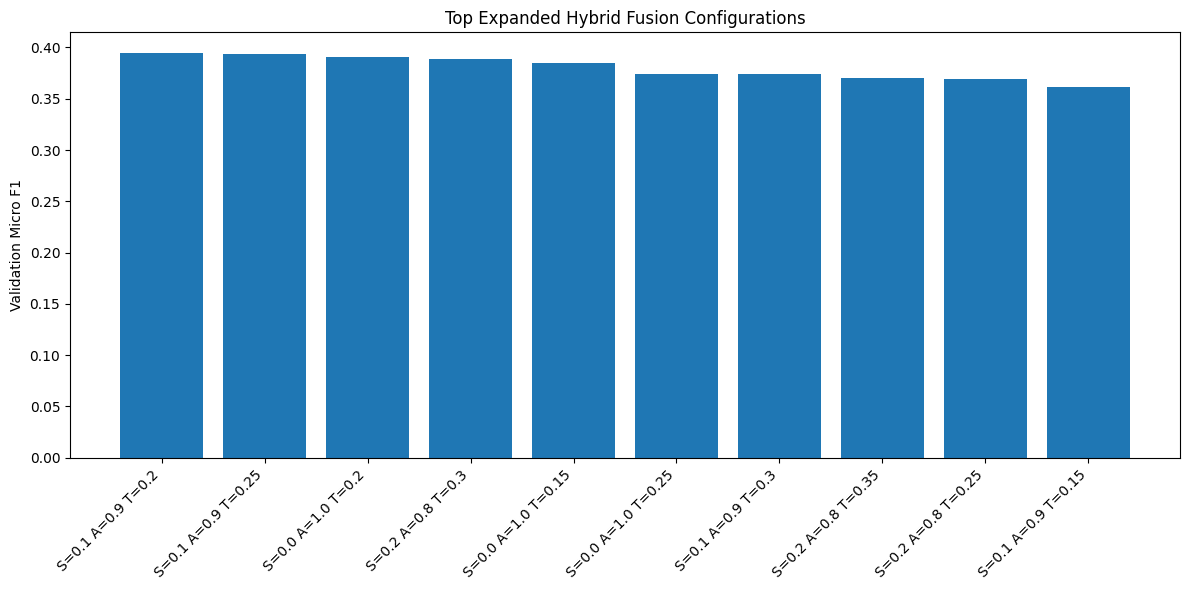

In [13]:
# ============================================================
# 12. PLOT TOP EXPANDED FUSION RESULTS
# ============================================================

plot_df = fusion_results_df.head(10).copy()
plot_df["Setting"] = (
    "S=" + plot_df["Structured Weight"].round(1).astype(str) +
    " A=" + plot_df["Audio Weight"].round(1).astype(str) +
    " T=" + plot_df["Threshold"].round(2).astype(str)
)

plt.figure(figsize=(12, 6))
plt.bar(plot_df["Setting"], plot_df["Micro F1"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Validation Micro F1")
plt.title("Top Expanded Hybrid Fusion Configurations")
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# 13. SAVE EXPANDED HYBRID OUTPUTS
# ============================================================

os.makedirs("../data/processed", exist_ok=True)

fusion_results_df.to_csv(
    "../data/processed/hybrid_multilabel_candidate150_expanded_fusion_search.csv",
    index=False
)

pd.DataFrame([hybrid_test_results]).to_csv(
    "../data/processed/hybrid_multilabel_candidate150_expanded_test_results.csv",
    index=False
)

comparison_df.to_csv(
    "../data/processed/hybrid_multilabel_candidate150_expanded_model_comparison.csv",
    index=False
)

np.save(
    "../data/processed/hybrid_multilabel_candidate150_expanded_test_probs.npy",
    fused_test_probs
)

np.save(
    "../data/processed/hybrid_multilabel_candidate150_expanded_test_pred.npy",
    fused_test_pred
)

np.save(
    "../data/processed/hybrid_multilabel_candidate150_expanded_y_test.npy",
    Y_test
)

np.save(
    "../data/processed/hybrid_multilabel_candidate150_expanded_test_track_ids.npy",
    structured_test_track_ids
)

np.save(
    "../data/processed/hybrid_multilabel_candidate150_expanded_label_columns.npy",
    np.array(label_cols)
)

with open("../data/processed/hybrid_multilabel_candidate150_expanded_best_config.txt", "w") as f:
    f.write(
        f"structured_weight={best_w_structured}\n"
        f"audio_weight={best_w_audio}\n"
        f"threshold={best_threshold}\n"
    )

print("Saved expanded hybrid multi-label outputs.")

Saved expanded hybrid multi-label outputs.


In [15]:
# ============================================================
# 14. INTERPRETATION NOTES
# ============================================================

print("1. This notebook combines the structured and expanded-audio multi-label branches on the exact same expanded split.")
print("2. Fusion is performed by weighted averaging of structured pseudo-probabilities and expanded audio probabilities.")
print("3. Validation data is used to tune both fusion weights and the final decision threshold.")
print("4. The final comparison shows whether the expanded hybrid system improves over the expanded audio-only baseline.")
print("5. The saved expanded hybrid outputs can support the final report, presentation, and deployment-style demos.")

1. This notebook combines the structured and expanded-audio multi-label branches on the exact same expanded split.
2. Fusion is performed by weighted averaging of structured pseudo-probabilities and expanded audio probabilities.
3. Validation data is used to tune both fusion weights and the final decision threshold.
4. The final comparison shows whether the expanded hybrid system improves over the expanded audio-only baseline.
5. The saved expanded hybrid outputs can support the final report, presentation, and deployment-style demos.
